FIRST FIVE ROWS
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  Setosa  
1  Setosa  
2  Setosa  
3  Setosa  
4  Setosa  

Dataset Shape:
(150, 5)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Species               object
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

Descriptive Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count

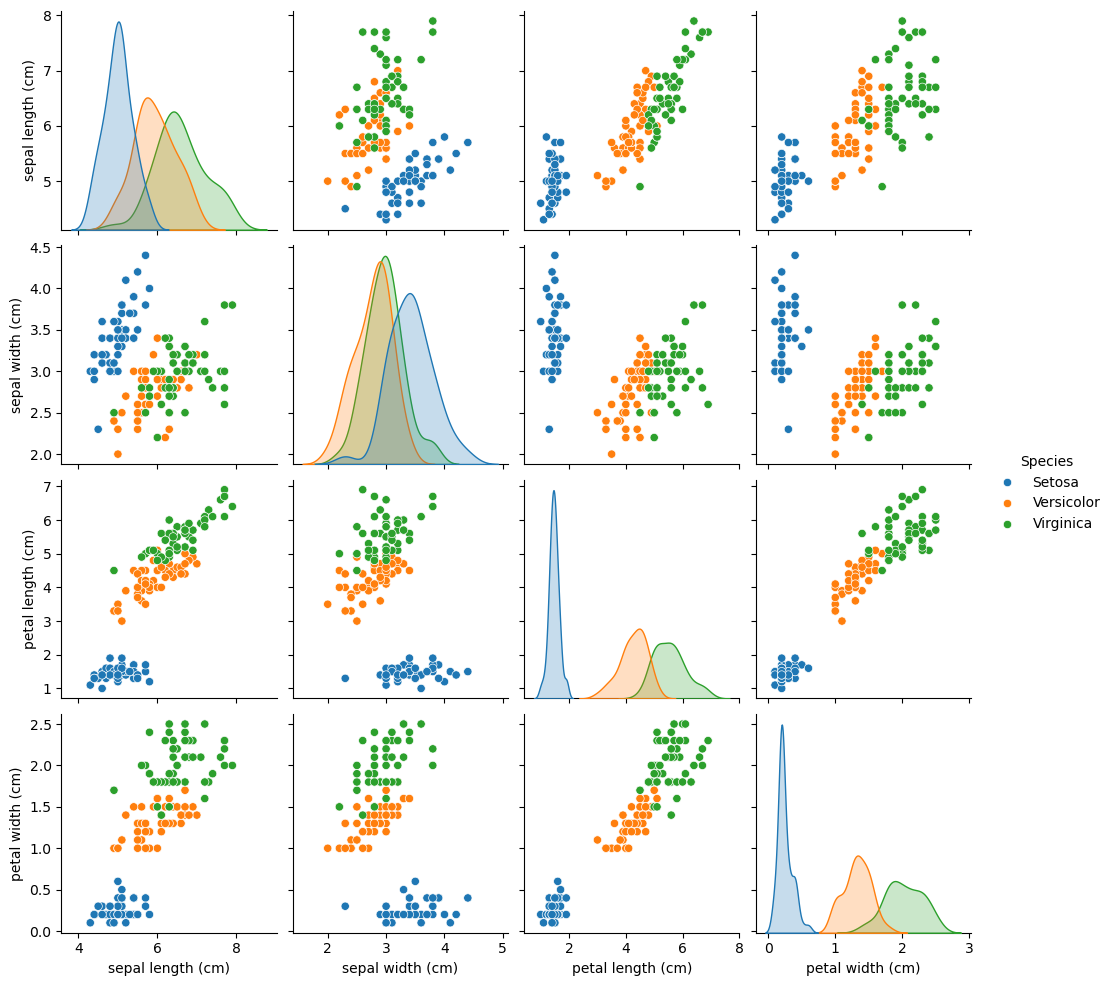

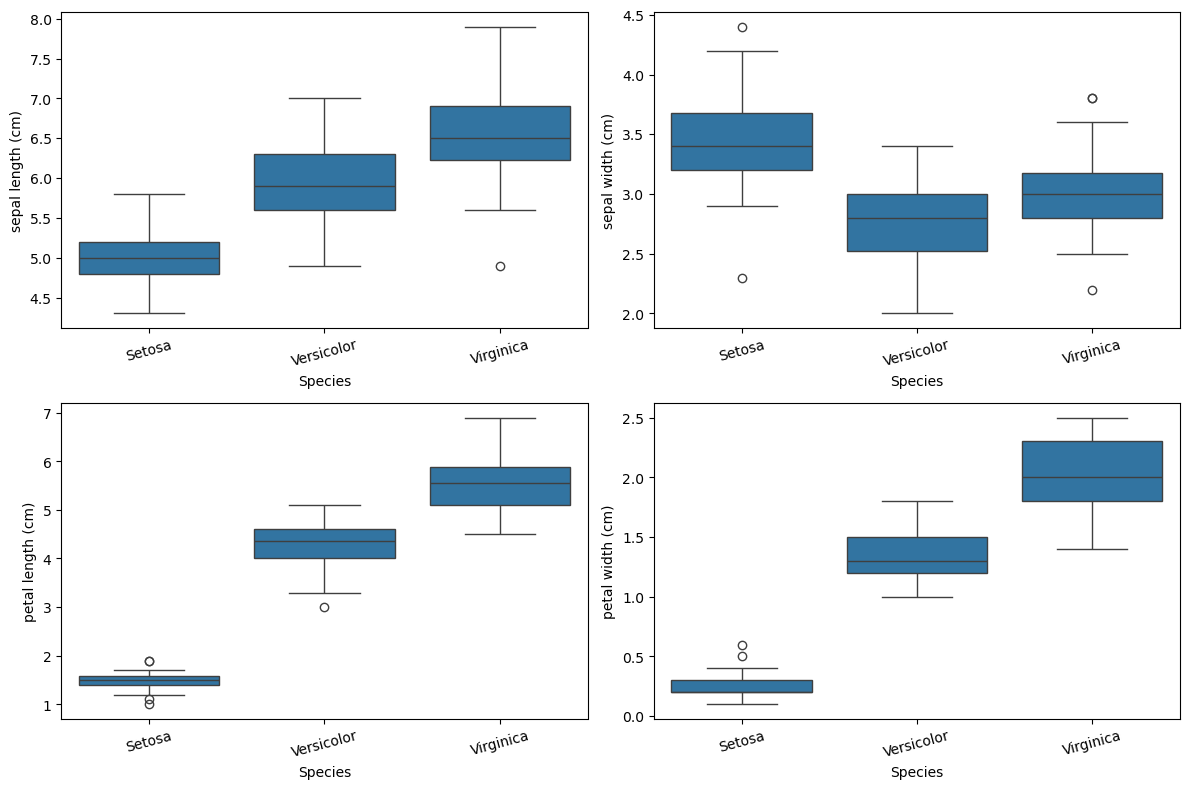

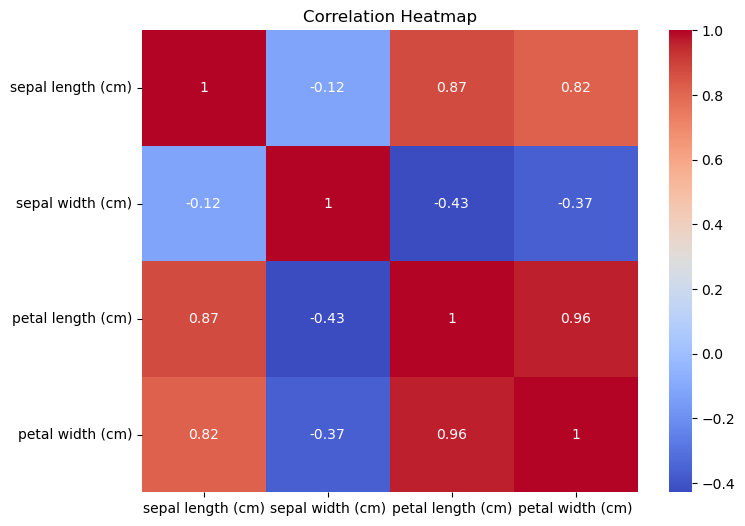


Most Important Features:
- Petal Length
- Petal Width
These two features separate the flower species most effectively.

Training Shape: (120, 4)
Testing Shape: (30, 4)


LOGISTIC REGRESSION RESULTS
Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



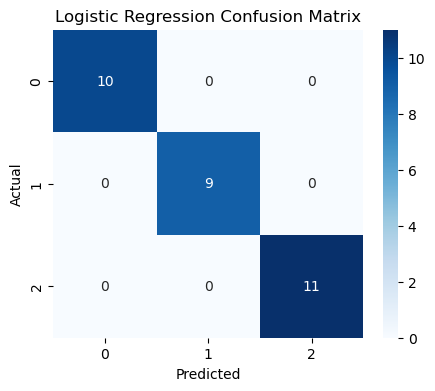



K-NEAREST NEIGHBORS RESULTS
Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



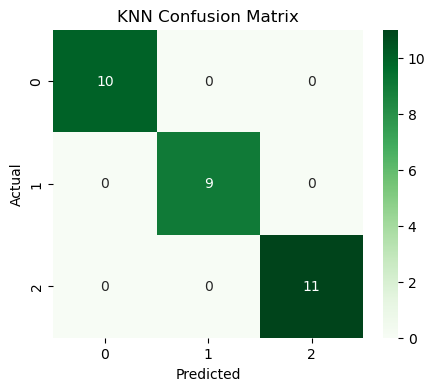



MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression       1.0
1  K-Nearest Neighbors       1.0


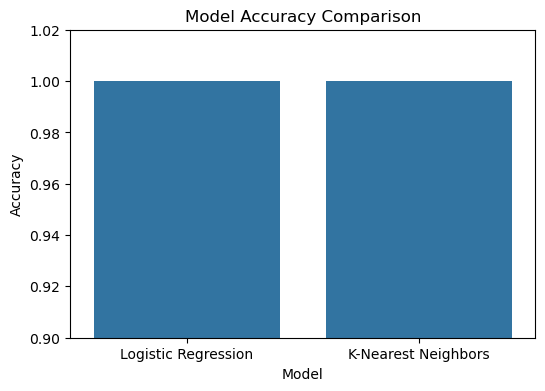



BEST MODEL
Model : Logistic Regression
Accuracy : 1.0


CONCLUSION

1. Loaded the Iris dataset from Scikit-learn.
2. Performed Exploratory Data Analysis (EDA).
3. Checked dataset shape, data types, missing values, and descriptive statistics.
4. Visualized the data using Pairplot, Boxplots, and Correlation Heatmap.
5. Identified Petal Length and Petal Width as the most discriminative features.
6. Split the dataset into 80% training and 20% testing data.
7. Trained two machine learning models:
      • Logistic Regression
      • K-Nearest Neighbors
8. Evaluated both models using:
      • Accuracy Score
      • Confusion Matrix
      • Classification Report
9. Compared the models and selected the one with the highest accuracy as the best-performing model.
10. The Iris dataset is small and well-separated, allowing both models to achieve very high accuracy.



In [3]:
# ==============================
# IRIS FLOWER CLASSIFICATION
# ==============================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

# ==============================
# Load Dataset
# ==============================

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = iris.target

species_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df["Species"] = df["Species"].map(species_names)

print("="*60)
print("FIRST FIVE ROWS")
print("="*60)
print(df.head())

# ==============================
# Exploratory Data Analysis
# ==============================

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

print("\nClass Distribution:")
print(df["Species"].value_counts())

# ==============================
# Pairplot
# ==============================

sns.pairplot(df, hue="Species")
plt.show()

# ==============================
# Boxplots
# ==============================

plt.figure(figsize=(12,8))

for i, feature in enumerate(iris.feature_names):
    plt.subplot(2,2,i+1)
    sns.boxplot(x="Species", y=feature, data=df)
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# ==============================
# Correlation Heatmap
# ==============================

plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("Species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ==============================
# Feature Selection Discussion
# ==============================

print("\nMost Important Features:")
print("- Petal Length")
print("- Petal Width")
print("These two features separate the flower species most effectively.")

# ==============================
# Prepare Data
# ==============================

X = iris.data
y = iris.target

# ==============================
# Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ==============================
# Logistic Regression
# ==============================

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("\n")
print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)

print("Accuracy:", lr_accuracy)

print("\nClassification Report")
print(classification_report(y_test, lr_pred, target_names=iris.target_names))

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# K-Nearest Neighbors
# ==============================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("\n")
print("="*60)
print("K-NEAREST NEIGHBORS RESULTS")
print("="*60)

print("Accuracy:", knn_accuracy)

print("\nClassification Report")
print(classification_report(y_test, knn_pred, target_names=iris.target_names))

cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# Model Comparison
# ==============================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        lr_accuracy,
        knn_accuracy
    ]
})

print("\n")
print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison)

plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x="Model", y="Accuracy")
plt.ylim(0.90,1.02)
plt.title("Model Accuracy Comparison")
plt.show()

# ==============================
# Best Model
# ==============================

best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("\n")
print("="*60)
print("BEST MODEL")
print("="*60)
print("Model :", best_model["Model"])
print("Accuracy :", best_model["Accuracy"])

# ==============================
# Conclusion
# ==============================

print("\n")
print("="*60)
print("CONCLUSION")
print("="*60)

print("""
1. Loaded the Iris dataset from Scikit-learn.
2. Performed Exploratory Data Analysis (EDA).
3. Checked dataset shape, data types, missing values, and descriptive statistics.
4. Visualized the data using Pairplot, Boxplots, and Correlation Heatmap.
5. Identified Petal Length and Petal Width as the most discriminative features.
6. Split the dataset into 80% training and 20% testing data.
7. Trained two machine learning models:
      • Logistic Regression
      • K-Nearest Neighbors
8. Evaluated both models using:
      • Accuracy Score
      • Confusion Matrix
      • Classification Report
9. Compared the models and selected the one with the highest accuracy as the best-performing model.
10. The Iris dataset is small and well-separated, allowing both models to achieve very high accuracy.
""")